In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW
from tqdm import tqdm

2025-08-22 19:41:13.470350: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755891673.664262      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755891673.722114      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


load data

In [2]:
df = pd.read_csv("/kaggle/input/data11/final_data.csv")
df = df[['Review', 'Rating']]

Label encoding

In [5]:

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['Rating'])
num_labels = len(label_encoder.classes_)

Train-test-split

In [6]:

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['Review'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

Tokenization

In [7]:

model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=64)
test_encodings = tokenizer(test_texts, truncation=True, padding=True, max_length=64)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

In [11]:
# 4. Dataset class

class ReviewDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

train_dataset = ReviewDataset(train_encodings, train_labels)
test_dataset = ReviewDataset(test_encodings, test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

load model

In [13]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
model.load_state_dict(torch.load("/kaggle/input/trained-distilbert-model/best_model.pt", map_location=device))  # Load your saved weights
model.to(device)
model.eval()

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using device: cuda


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


model & optimizer

In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

Using device: cuda


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Training

In [ ]:

num_epochs = 10
patience = 5   # stop if no improvement for 5 epochs
best_val_loss = float("inf")
epochs_no_improve = 0

for epoch in range(num_epochs):
    #  Training
    model.train()
    total_loss = 0
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1} Training"):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_train_loss = total_loss / len(train_loader)

    #  Validation 
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Epoch {epoch+1} Validation"):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            val_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_val_loss = val_loss / len(test_loader)

    print(f"\nEpoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")

    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pt")  # save best model
        print("✅ Model improved and saved!")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("⏹ Early stopping triggered!")
            break

Epoch 1 Validation: 100%|██████████| 8546/8546 [04:40<00:00, 30.49it/s]



Epoch 1: Train Loss = 1.0329, Val Loss = 0.9961
✅ Model improved and saved!


Epoch 2 Validation: 100%|██████████| 8546/8546 [04:40<00:00, 30.46it/s]



Epoch 2: Train Loss = 0.9462, Val Loss = 0.9751
✅ Model improved and saved!


Epoch 3 Validation: 100%|██████████| 8546/8546 [04:39<00:00, 30.55it/s]


...

Epoch 4 Validation: 100%|██████████| 8546/8546 [04:40<00:00, 30.41it/s]



Epoch 4: Train Loss = 0.8140, Val Loss = 1.0210


Epoch 5 Validation: 100%|██████████| 8546/8546 [04:40<00:00, 30.45it/s]



Epoch 5: Train Loss = 0.7406, Val Loss = 1.0918


Epoch 6 Training:   6%|▋         | 2212/34181 [03:55<56:51,  9.37it/s] 

Evaluate trained model

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns


Classification Report:
              precision    recall  f1-score   support

         1.0       0.64      0.67      0.65     25337
         2.0       0.44      0.36      0.40     23128
         3.0       0.49      0.54      0.51     31123
         4.0       0.56      0.48      0.52     29640
         5.0       0.68      0.80      0.74     27495

    accuracy                           0.57    136723
   macro avg       0.56      0.57      0.56    136723
weighted avg       0.56      0.57      0.57    136723


Confusion Matrix:
[[16920  5246  2642   225   304]
 [ 6899  8436  6800   637   356]
 [ 2268  4711 16656  5931  1557]
 [  344   654  6541 14224  7877]
 [  192   152  1083  4188 21880]]

✅ Overall Accuracy: 0.5713


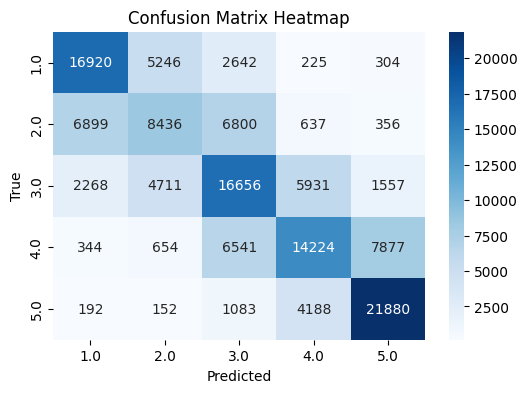

In [18]:

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        preds = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# 7. Metrics

acc = accuracy_score(all_labels, all_preds)
class_names = [str(c) for c in label_encoder.classes_]

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

print("\nConfusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

print(f"\n✅ Overall Accuracy: {acc:.4f}")


# 8. Confusion Matrix Heatmap 

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(all_labels, all_preds),
            annot=True, fmt='d', cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix Heatmap")
plt.show()